## Load the tokenizer

In [1]:
import sys
sys.path.append('..')

In [2]:
from minbpe import BasicTokenizer

tokenizer = BasicTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: BasicTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

## Create the model

In [3]:
import torch
torch.manual_seed(3647)
torch.set_float32_matmul_precision('high')

In [4]:
from variant_gpt.models import GPT2Config, GPT2Model

config = GPT2Config(vocab_size=get_vocab_size(tokenizer), device='cuda' if torch.cuda.is_available() else 'cpu')

model = GPT2Model(config)
model = torch.compile(model)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

number of parameters: 85.85M
86.636544 M parameters


## Data preparation

In [5]:
import sys
print(sys.executable)

/home/valerio/workspace/variantGPT/.venv/bin/python3.12


### 1. Load the data

In [6]:
with open("../output/combined_text.txt", "r", encoding='utf-8') as f:
    text_sequence = f.read()

encoded_text_sequence = tokenizer.encode(text_sequence)
len(encoded_text_sequence)

816962

### 2. Split it into train and test

In [7]:
data = torch.tensor(encoded_text_sequence, dtype=torch.long)
split_index = int(0.9 * len(data))
train_data = data[:split_index]
val_data = data[split_index:]

### 3. Data loader

In [8]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        if len(data) <= block_size:
            raise ValueError(
                f"The length of the data ({len(data)}) must be greater than the block_size ({block_size})."
            )

        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index : index + self.block_size]
        y = self.data[index + 1 : index + self.block_size + 1]
        return x, y


def get_dataloaders(
    train_data: torch.Tensor,
    val_data: torch.Tensor,
    block_size: int,
    batch_size: int,
    device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [9]:
batch_size = 32

train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=config.block_size,
    batch_size=batch_size,
    device=config.device,
)
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([32, 1024]), torch.Size([32, 1024]))

### 4. Training

In [10]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    eval_iters: int
) -> Dict[str, float]:
    was_training = model.training
    model.eval()

    results: Dict[str, float] = {}
    device = next(model.parameters()).device

    for split_name, loader in [('train', train_loader), ('val', val_loader)]:
        losses = []

        for i, (x, y) in enumerate(loader):
            if i >= eval_iters:
                break
            x, y = x.to(device), y.to(device)

            # Expecting model to return (logits, loss)
            _, loss = model(x, y)
            losses.append(loss.item())

        results[split_name] = float(torch.tensor(losses).mean())

    if was_training:
        model.train()

    return results

In [11]:
def save_checkpoint(
    model: GPT2Model,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [12]:
env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [ ]:
from tqdm.notebook import tqdm

max_iters = 1
eval_interval = 1000
eval_iters = 200
learning_rate = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=config.block_size,
    batch_size=batch_size,
    device=config.device
)

train_losses = []
val_losses = []

for iteration in range(max_iters):
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch {iteration+1}/{max_iters}"
    )

    for batch_idx, (x_batch, y_batch) in progress_bar:
        # Training step
        logits, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        progress_bar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

        # Evaluation
        if batch_idx % eval_interval == 0 or batch_idx == len(train_loader) - 1:
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                eval_iters=min(eval_iters, len(val_loader))
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            tqdm.write(
                f"[Epoch {iteration+1} | Step {batch_idx:>5d}] "
                f"Train Loss: {losses['train']:.4f} | "
                f"Val Loss: {losses['val']:.4f}"
            )

    # Save checkpoint
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=iteration,
        loss=loss.item(),
        file_path=f"../output/pre_training/run_4/checkpoint_{iteration}.pth"
    )

tqdm.write("\nTraining completed ✅")

Epoch 1/1:   0%|          | 0/22946 [00:00<?, ?it/s]

[Epoch 1 | Step     0] Train Loss: 6.5931 | Val Loss: 6.6377
[Epoch 1 | Step  1000] Train Loss: 0.2967 | Val Loss: 5.8763


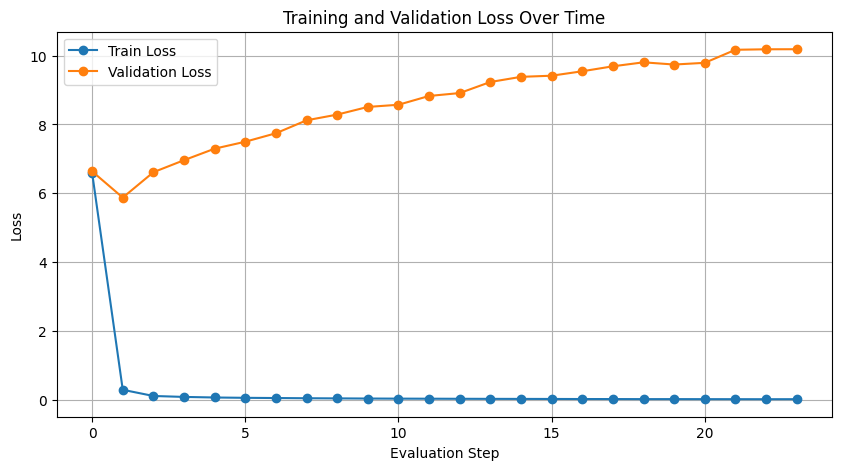

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [16]:
input_tokens = tokenizer.encode("Buongiorno ")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(config.device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

Buongiorno Chi è il Compleanno dell'Unostro Presidente... Cius? No Si, fate in questa volta di quelle "ragione" come in fotova e cantene Lo diabbiamo tutti 🤣🤣🤣 Dovrusti così anche a fine gara tutti 🤟🏻 😂😂😂 @⁨~Filippo⁩  ma il tuo è un arbitrato sul cao
